# MobileNetV2 Transfer Learning

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
GROUP_CHUNK_SIZE = 20
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.10.0


In [2]:
try:
    tf.config.set_visible_devices([], 'GPU')
except Exception as error:
    print('GPU visibility already fixed:', error)

print('Visible GPUs:', tf.config.get_visible_devices('GPU'))


Visible GPUs: []


In [ ]:
def find_dataset_root() -> Path:
    candidates = [
        Path.cwd() / 'Dataset',
        Path.cwd().parent / 'Dataset',
        Path.cwd().parent.parent / 'Dataset',
        Path('C:/Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk/CVProject/Dataset')
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            class_dirs = [p for p in candidate.iterdir() if p.is_dir()]
            if class_dirs:
                return candidate.resolve()
    raise FileNotFoundError('Could not find the finalized Dataset folder.')

def natural_key(path: Path):
    parts = re.split(r'(\d+)', path.stem)
    return [int(part) if part.isdigit() else part.lower() for part in parts]

def extract_group_key(path: Path) -> str:
    match = re.search(r'(\d+)$', path.stem)
    chunk_id = int(match.group(1)) // GROUP_CHUNK_SIZE if match else 0
    prefix = re.sub(r'[_-]?\d+$', '', path.stem)
    return f'{path.parent.name}::{prefix}::chunk_{chunk_id:04d}'

def build_split_lists(dataset_root: Path, val_split: float = VAL_SPLIT):
    class_names = sorted([p.name for p in dataset_root.iterdir() if p.is_dir()])
    train_paths, train_labels = [], []
    val_paths, val_labels = [], []
    split_summary = []

    for class_index, class_name in enumerate(class_names):
        class_dir = dataset_root / class_name
        class_files = sorted([p for p in class_dir.iterdir() if p.is_file()], key=natural_key)
        grouped_files = {}
        for file_path in class_files:
            group_key = extract_group_key(file_path)
            grouped_files.setdefault(group_key, []).append(str(file_path))

        ordered_groups = sorted(grouped_files.items(), key=lambda item: item[0])
        val_group_count = max(1, int(round(len(ordered_groups) * val_split)))
        val_group_keys = {group_key for group_key, _ in ordered_groups[-val_group_count:]}

        class_train = 0
        class_val = 0
        for group_key, grouped_paths in ordered_groups:
            target_paths, target_labels = (val_paths, val_labels) if group_key in val_group_keys else (train_paths, train_labels)
            target_paths.extend(grouped_paths)
            target_labels.extend([class_index] * len(grouped_paths))
            if group_key in val_group_keys:
                class_val += len(grouped_paths)
            else:
                class_train += len(grouped_paths)

        split_summary.append({
            'class_name': class_name,
            'groups': len(ordered_groups),
            'train_images': class_train,
            'val_images': class_val
        })

    return class_names, train_paths, train_labels, val_paths, val_labels, split_summary

def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(paths, labels, training=False):
    path_arr = np.array(paths)
    label_arr = np.array(labels, dtype=np.int32)

    if training and len(path_arr) > 0:
        rng = np.random.default_rng(SEED)
        order = rng.permutation(len(path_arr))
        path_arr = path_arr[order]
        label_arr = label_arr[order]

    ds = tf.data.Dataset.from_tensor_slices((path_arr, label_arr))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

DATASET_ROOT = find_dataset_root()
CLASS_NAMES, train_paths, train_labels, val_paths, val_labels, split_summary = build_split_lists(DATASET_ROOT)
NUM_CLASSES = len(CLASS_NAMES)

print('Dataset root:', DATASET_ROOT)
print('Classes:', CLASS_NAMES)
print('Number of classes:', NUM_CLASSES)
print('Train images:', len(train_paths))
print('Validation images:', len(val_paths))
print('Sequence-aware split summary:')
for row in split_summary:
    print(row)

Dataset root: C:\Users\user\Desktop\behavior-detection\DLProject\Dataset
Classes: ['distracted', 'fatigue', 'focused', 'raise_hand', 'sleeping', 'using_smartphone', 'writing_reading']
Number of classes: 7
Train images: 6863
Validation images: 1697
Sequence-aware split summary:
{'class_name': 'distracted', 'groups': 80, 'train_images': 1181, 'val_images': 301}
{'class_name': 'fatigue', 'groups': 52, 'train_images': 714, 'val_images': 172}
{'class_name': 'focused', 'groups': 146, 'train_images': 2285, 'val_images': 573}
{'class_name': 'raise_hand', 'groups': 54, 'train_images': 683, 'val_images': 177}
{'class_name': 'sleeping', 'groups': 41, 'train_images': 637, 'val_images': 152}
{'class_name': 'using_smartphone', 'groups': 25, 'train_images': 348, 'val_images': 88}
{'class_name': 'writing_reading', 'groups': 65, 'train_images': 1015, 'val_images': 234}


In [4]:
train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
class_names = CLASS_NAMES

In [5]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(
    64,
    activation='relu',
    kernel_regularizer=keras.regularizers.l2(5e-4)
)(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs)
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                      

In [6]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/12


215/215 [==============================] - 86s 391ms/step - loss: 1.8682 - accuracy: 0.4616 - val_loss: 1.6835 - val_accuracy: 0.3754 - lr: 5.0000e-05
Epoch 2/12
215/215 [==============================] - 98s 457ms/step - loss: 0.6960 - accuracy: 0.7811 - val_loss: 1.2836 - val_accuracy: 0.5516 - lr: 5.0000e-05
Epoch 3/12
215/215 [==============================] - 82s 383ms/step - loss: 0.4029 - accuracy: 0.8855 - val_loss: 1.1853 - val_accuracy: 0.6040 - lr: 5.0000e-05
Epoch 4/12
215/215 [==============================] - 80s 374ms/step - loss: 0.2804 - accuracy: 0.9308 - val_loss: 1.1357 - val_accuracy: 0.6400 - lr: 5.0000e-05
Epoch 5/12
215/215 [==============================] - 81s 379ms/step - loss: 0.2294 - accuracy: 0.9478 - val_loss: 1.0530 - val_accuracy: 0.6647 - lr: 5.0000e-05
Epoch 6/12
215/215 [==============================] - 84s 391ms/step - loss: 0.1843 - accuracy: 0.9612 - val_loss: 0.9838 - val_accuracy: 0.6877 - lr: 5.0000e-05
Epoch 7/12
215/215 [===================

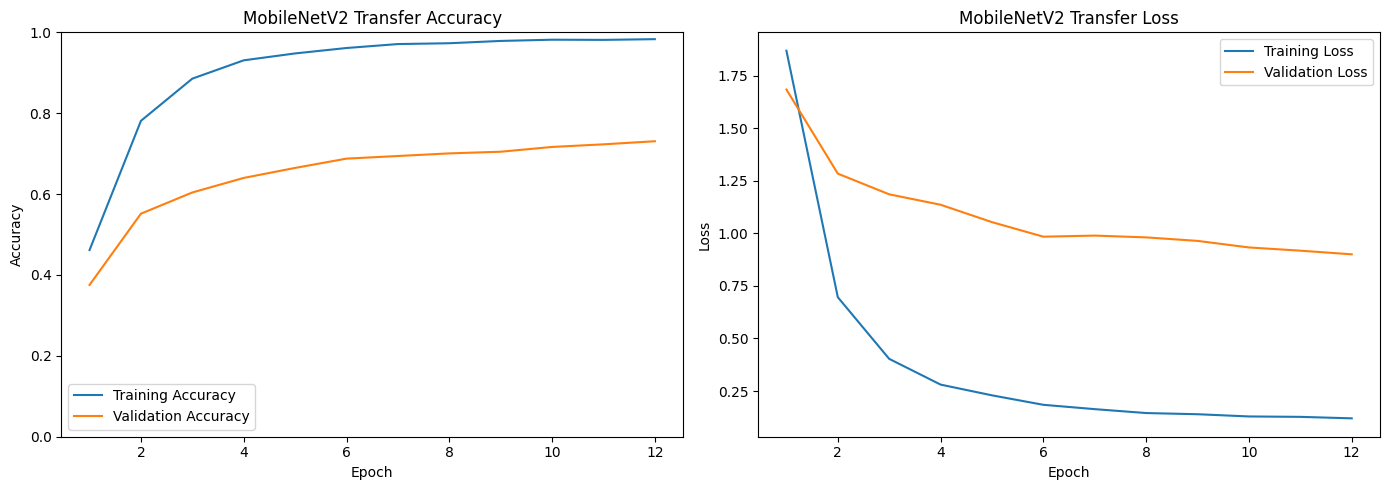

In [7]:
def plot_history(history, title_prefix='Model'):
    history_dict = history.history
    epochs = range(1, len(history_dict['loss']) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history_dict['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.0)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict['loss'], label='Training Loss')
    plt.plot(epochs, history_dict['val_loss'], label='Validation Loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()

plot_history(history, 'MobileNetV2 Transfer')

54/54 [==============================] - 16s 284ms/step
                  precision    recall  f1-score   support

      distracted       0.88      0.94      0.91       301
         fatigue       0.31      0.32      0.32       172
         focused       0.90      0.70      0.79       573
      raise_hand       0.44      0.98      0.61       177
        sleeping       0.79      0.20      0.32       152
using_smartphone       0.97      0.73      0.83        88
 writing_reading       0.90      1.00      0.95       234

        accuracy                           0.73      1697
       macro avg       0.74      0.70      0.67      1697
    weighted avg       0.79      0.73      0.73      1697



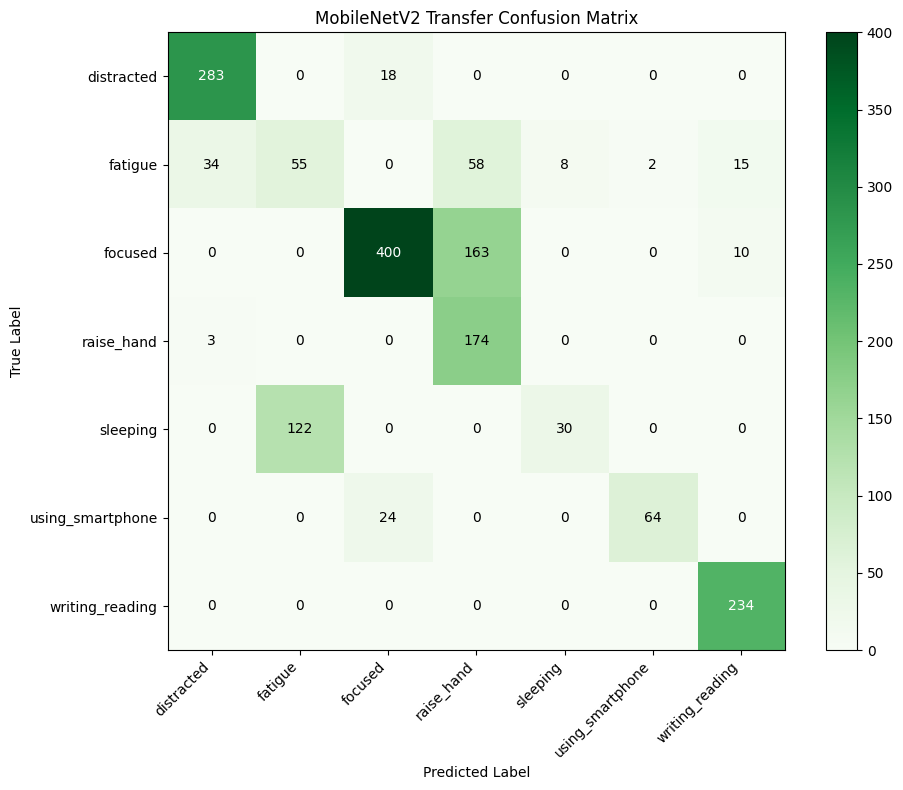

In [8]:
y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)
y_prob = transfer_model.predict(val_ds)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Greens')
plt.title('MobileNetV2 Transfer Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

threshold = cm.max() / 2 if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()

print(classification_report(y_true, y_pred, target_names=class_names))